# Lara's notities

## Preprocessen/sample methoden
The pipeline described by MNE is https://mne.tools/stable/documentation/cookbook.html is VERY detailed. I think our data is already quite polished maybe? They only talk about downsampling and normalization in the project description so maybe such things are more complicated than needed. 
Do downsampling with basic factor 10 right now and do average pooling, factor can be bigger when slow. PCA for dimension reduction?
Z-score normalization can be better then min-max when amplitudes vary a lot for the MEG data (z-score uses the normal distribution while min-max is linear, https://www.codecademy.com/article/min-max-zscore-normalization).

Total steps: read data, downsample data, stack the data to one x_train, normalize the data.

## (a) Modellen om uit te kiezen
MNE tools are made for MEG analysis and visualization. Also learning? sklearn. Could do normal classification too maybe. 

I chose 1D CNN becauseee it seems fine (survey: https://www.sciencedirect.com/science/article/pii/S0888327020307846).

Model: 1D CNN, optimizer Adam, Loss function Entropyloss. Memory management with batches of size 16.
No grid search on parameters or other models.

## (b) Test framework voor zowel cross als intra testen
Done.

## (c) Hyperparameter tweaking framework
TO DO!

We moeten vooral ook beschrijven hoe we verbeteren enzo. Miss een soort labjournaal bijhouden?

In [14]:
%pip install torch numpy scipy scikit-learn matplotlib h5py mne

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Read data

In [20]:
import os
import glob
import h5py
import numpy as np

# Functions to load/get/extract adminstrative stuff
def get_dataset_name(file_name_with_dir):
    file_name_without_dir = os.path.basename(file_name_with_dir)
    temp = file_name_without_dir.split(".")[:-1]
    dataset_name = "".join(temp)
    return dataset_name

def load_h5_file(filepath):
    with h5py.File(filepath, 'r') as f: # use with to close it interestingly
        dataset_name = list(f.keys())[0]
        return f[dataset_name][()]      # Outputs matrix that is the numpy array of the data in the h5py file

def get_label(filepath):    # extract classification activity label: 0="rest", 1="math", 2="memory" en 3="motor"
    name = os.path.basename(filepath)
    if name.startswith("rest"):     # maybe slow sorry, idk how else to do this. 10s valt mee
        return 0
    elif "math" in name:
        return 1
    elif "memory" in name:
        return 2
    elif "motor" in name:
        return 3
    else:
        raise ValueError(f"Unknown label for file: {name}")     # This happens apparently :/ OHWWHW it starts with task

# downsample when loading data
def downsample(matrix, factor=10):
    nsensors, ntimesteps = matrix.shape
    down_ntimesteps = ntimesteps // factor
    matrix = matrix[:, :down_ntimesteps * factor]
    matrix = matrix.reshape(nsensors,down_ntimesteps,factor).mean(axis=2)
    return matrix

# load a folder of data!
def load_folder(folder):
    x = []
    y = []
    files = glob.glob(os.path.join("data", folder, "*.h5"))
    # print(files)
    for file in files:
        matrix = load_h5_file(file)
        matrix = downsample(matrix)
        x.append(matrix)        # now has for every file a matrix with different measurers and different timesteps, so (number, channels, timesteps)
        y.append(get_label(file))
    return np.array(x), np.array(y)

# Load all the data (maybe requires too much memory?)
x_train_intra, y_train_intra = load_folder(r"Intra\train")
x_test_intra, y_test_intra = load_folder(r"Intra\test")

x_train_cross, y_train_cross = load_folder(r"Cross\train")
x_test_cross1, y_test_cross1 = load_folder(r"Cross\test1")
x_test_cross2, y_test_cross2 = load_folder(r"Cross\test2")
x_test_cross3, y_test_cross3 = load_folder(r"Cross\test3")

# Preprocessing
z-score normalization

In [21]:
from sklearn.preprocessing import StandardScaler

# Normalization via z-score sklearn standardscaler. We have to scale back the data to a 2d array first, then we normalize, then we construct the train/test again.
def normalize(train, test):
    n, c, t = train.shape
    scaler = StandardScaler()
    train_2d = train.transpose(0, 2, 1).reshape(-1, c)
    test_2d  = test.transpose(0, 2, 1).reshape(-1, c)
    train_2d = scaler.fit_transform(train_2d)
    test_2d = scaler.transform(test_2d)
    train = train_2d.reshape(n, t, c).transpose(0, 2, 1)
    test  = test_2d.reshape(test.shape[0], t, c).transpose(0, 2, 1)
    return train, test

# Normalize all data (repeated code oh well)
x_train_intra, x_test_intra = normalize(x_train_intra, x_test_intra)
x_train_cross, x_test_cross1 = normalize(x_train_cross, x_test_cross1)
_, x_test_cross2 = normalize(x_train_cross, x_test_cross2)
_, x_test_cross3 = normalize(x_train_cross, x_test_cross3)

# Model training and testing methods

In [15]:
import torch
from torch.utils.data import Dataset
import torch.nn as nn

from torch.utils.data import DataLoader
import torch.optim as optim

# We use torch once again. This modifies data to make it fit.
class Torchdata(Dataset):
    def __init__(self, x, y):
        x = np.asarray(x, dtype=np.float32)
        y = np.asarray(y, dtype=np.int64)
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, xid):
        return self.x[xid], self.y[xid]

# UPDATED: Now accepts dropout_rate
class CNN(nn.Module):
    def __init__(self, channels, input_length, dropout_rate=0.5): 
        super().__init__()
        self.conv1 = nn.Conv1d(channels, 64, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(4)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

        with torch.no_grad():
            dummy = torch.zeros(1, channels, input_length)
            x = self.pool(self.relu(self.conv1(dummy)))
            x = self.pool(self.relu(self.conv2(x)))
            self.dyn_size = x.shape[1] * x.shape[2]
            
        self.fc1 = nn.Linear(self.dyn_size, 128)
        self.fc2 = nn.Linear(128, 4)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# UPDATED: Now accepts lr, batch_size, and dropout_rate
def train_model(x_train, y_train, epochs=15, lr=0.001, batch_size=16, dropout_rate=0.5):
    dataset = Torchdata(x_train, y_train)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True) 
    
    model   = CNN(x_train.shape[1], x_train.shape[2], dropout_rate=dropout_rate) 
    device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr) 
    loss_function = torch.nn.CrossEntropyLoss()
 
    loss_history = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
 
        loss_history.append(total_loss)
        if total_loss < 1e-9: 
            break
 
    return model, loss_history

def evaluate(model, x, y):
    dataset = Torchdata(x, y)
    loader = DataLoader(dataset, batch_size=16)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(x_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    return correct / total

# Hyperparameter Tuning

In [16]:
import itertools

def create_param_grid():
    param_grid = {
        'lr': [0.001, 0.0001],
        'batch_size': [16, 32],
        'factor': [5, 10, 20],
        'dropout_rate': [0.2, 0.5] # added dropout just to try
    }
    
    keys, values = zip(*param_grid.items())
    experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]
    return experiments

def run_hyperparameter_search(x_train, y_train, x_val, y_val):
    experiments = create_param_grid()
    best_acc = 0
    best_params = None

    results_log = [] 

    for params in experiments:
        print(f"Testing params: {params}")
        trained_model, loss_history = train_model(
            x_train, y_train, 
            epochs=10, 
            lr=params['lr'], 
            batch_size=params['batch_size'], 
            dropout_rate=params['dropout_rate']
        )
        
        val_acc = evaluate(trained_model, x_val, y_val)
        print(f"Validation Accuracy: {val_acc:.4f}\n")
        

        results_log.append({'params': params, 'val_acc': val_acc})
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_params = params
            
    print(f"Best Validation Accuracy: {best_acc} with {best_params}")
    return best_params, results_log

# Hyperparameter Testing

In [17]:
best_params, logs = run_hyperparameter_search(x_train_cross, y_train_cross, x_test_cross1, y_test_cross1)

Testing params: {'lr': 0.001, 'batch_size': 16, 'factor': 5, 'dropout_rate': 0.2}
Validation Accuracy: 0.5625

Testing params: {'lr': 0.001, 'batch_size': 16, 'factor': 5, 'dropout_rate': 0.5}
Validation Accuracy: 0.8750

Testing params: {'lr': 0.001, 'batch_size': 16, 'factor': 10, 'dropout_rate': 0.2}
Validation Accuracy: 0.6875

Testing params: {'lr': 0.001, 'batch_size': 16, 'factor': 10, 'dropout_rate': 0.5}
Validation Accuracy: 0.6875

Testing params: {'lr': 0.001, 'batch_size': 16, 'factor': 20, 'dropout_rate': 0.2}
Validation Accuracy: 0.6250

Testing params: {'lr': 0.001, 'batch_size': 16, 'factor': 20, 'dropout_rate': 0.5}
Validation Accuracy: 0.6250

Testing params: {'lr': 0.001, 'batch_size': 32, 'factor': 5, 'dropout_rate': 0.2}
Validation Accuracy: 0.6250

Testing params: {'lr': 0.001, 'batch_size': 32, 'factor': 5, 'dropout_rate': 0.5}
Validation Accuracy: 0.9375

Testing params: {'lr': 0.001, 'batch_size': 32, 'factor': 10, 'dropout_rate': 0.2}
Validation Accuracy: 0.62

KeyboardInterrupt: 

# Do the training and the testing
Na een aantal epochs als de loss functie duidelijk geconvergeerd is naar 0 gaat hij nog steeds door :/. Nu gefixt met break.

## Result
Took me only 2 m 5.8 s
Intra-subject accuracy: 1.0
Cross-subject 1 accuracy: 0.6875
Cross-subject 2 accuracy: 0.25
Cross-subject 3 accuracy: 0.25

Without downsampling:
Took me 2 m 51.7 s
Intra-subject accuracy: 1.0
Cross-subject 1 accuracy: 0.8125
Cross-subject 2 accuracy: 0.25
Cross-subject 3 accuracy: 0.25

In [18]:
# Intra
model_intra, loss_intra = train_model(x_train_intra, y_train_intra)
acc_intra = evaluate(model_intra, x_test_intra, y_test_intra)
print("Intra-subject accuracy:", acc_intra)

# Cross
model_cross, loss_cross = train_model(x_train_cross, y_train_cross)
acc_cross1 = evaluate(model_cross, x_test_cross1, y_test_cross1)
acc_cross2 = evaluate(model_cross, x_test_cross2, y_test_cross2)
acc_cross3 = evaluate(model_cross, x_test_cross3, y_test_cross3)
print("Cross-subject 1 accuracy:", acc_cross1)
print("Cross-subject 2 accuracy:", acc_cross2)
print("Cross-subject 3 accuracy:", acc_cross3)

Epoch 0  Loss: 1.990751
Epoch 1  Loss: 0.004969
Epoch 2  Loss: 0.000000
Epoch 3  Loss: 0.000000
Intra-subject accuracy: 1.0
Epoch 0  Loss: 4.503901
Epoch 1  Loss: 0.627761
Epoch 2  Loss: 0.151707
Epoch 3  Loss: 0.695768
Epoch 4  Loss: 0.356803
Epoch 5  Loss: 0.000691
Epoch 6  Loss: 0.229589
Epoch 7  Loss: 0.000623
Epoch 8  Loss: 0.262919
Epoch 9  Loss: 1.468926
Epoch 10  Loss: 0.004925
Epoch 11  Loss: 1.704743
Epoch 12  Loss: 0.000005
Epoch 13  Loss: 0.638183
Epoch 14  Loss: 0.042487
Epoch 15  Loss: 0.000000
Cross-subject 1 accuracy: 0.6875
Cross-subject 2 accuracy: 0.25
Cross-subject 3 accuracy: 0.25


# Data And Results Visualization and Analysis

This section will not modify the output or data, but instead visualize and summarise it in ways to make it easier to see what the hyperparameters do. 


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import torch
from torch.utils.data import DataLoader
import mne
 
LABEL_NAMES = ["Rest", "Math", "Memory", "Motor"]
COLORS      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

## Raw signal data
We visualize the raw data so we have an idea of what we're working with.

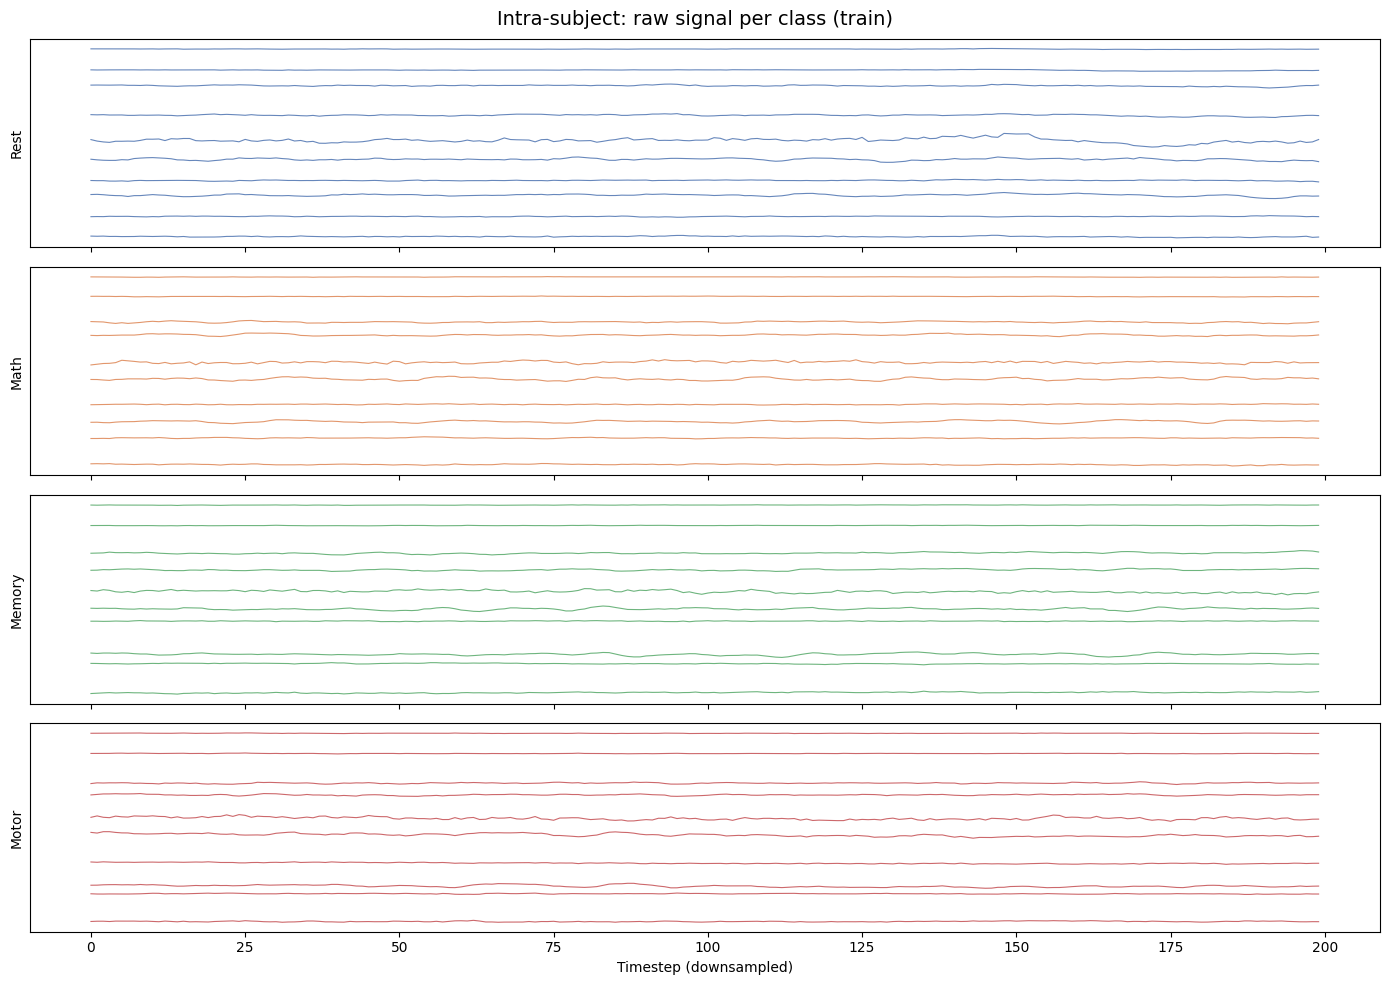

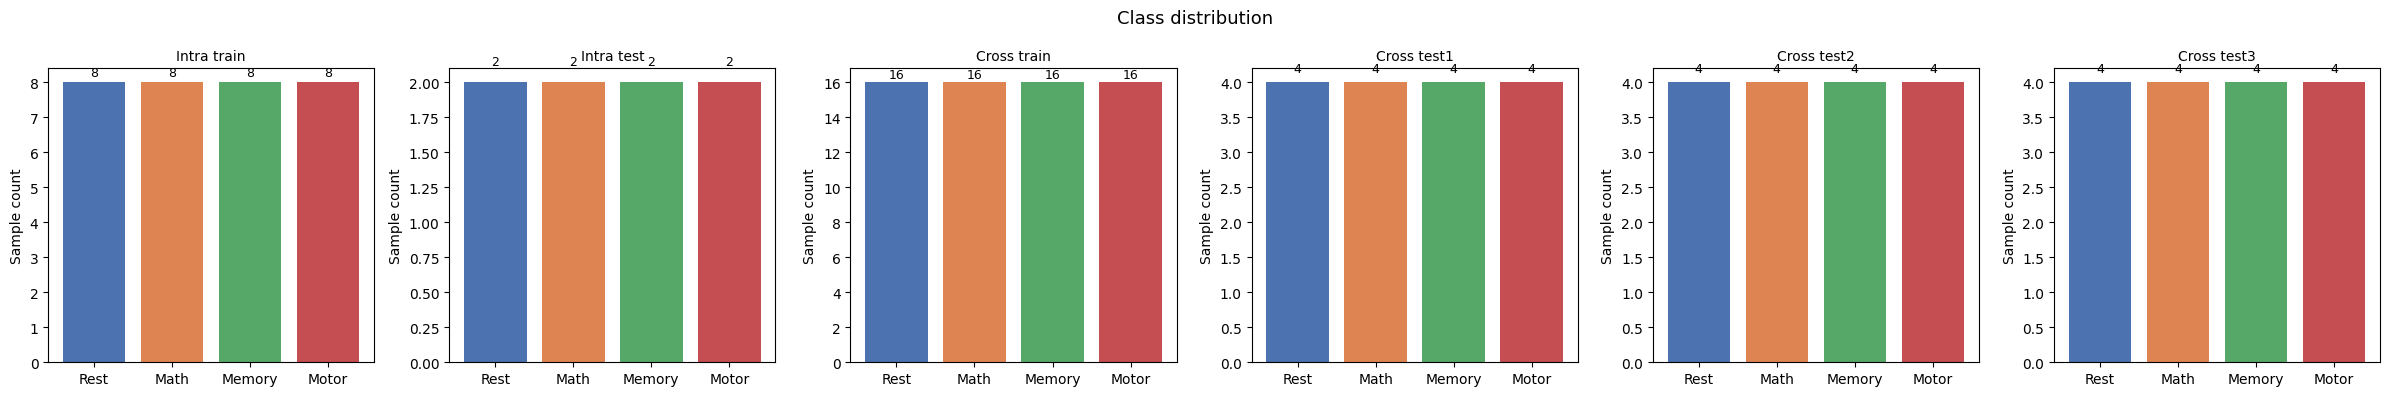

In [20]:
def plot_raw_samples(x, y, n_sensors=10, n_timesteps=200, title="Raw signal samples"):
    """
    Plot the first `n_sensors` channels for one example per class.
    x : (n_samples, channels, timesteps)
    y : (n_samples,)
    """
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(title, fontsize=14)
 
    for label_idx, (label_name, color) in enumerate(zip(LABEL_NAMES, COLORS)):
        ax = axes[label_idx]
        matches = np.where(y == label_idx)[0]
        if len(matches) == 0:
            ax.set_ylabel(label_name)
            ax.text(0.5, 0.5, "No samples", transform=ax.transAxes, ha="center")
            continue
 
        sample = x[matches[0], :n_sensors, :n_timesteps]  # (n_sensors, t)
        t = np.arange(sample.shape[1])
 
        # offset each sensor trace vertically so they don't overlap
        offset = 3.0
        for i, trace in enumerate(sample):
            ax.plot(t, trace + i * offset, color=color, linewidth=0.8, alpha=0.85)
 
        ax.set_ylabel(label_name, fontsize=10)
        ax.set_yticks([])
 
    axes[-1].set_xlabel("Timestep (downsampled)")
    plt.tight_layout()
    plt.savefig("figs/raw_signal_samples.png", dpi=150)
    plt.show()
 
plot_raw_samples(x_train_intra, y_train_intra, title="Intra-subject: raw signal per class (train)")

def plot_class_distribution(*datasets):
    """
    datasets : list of (name, y_array) tuples
    """
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
 
    for ax, (name, y) in zip(axes, datasets):
        counts = [np.sum(y == i) for i in range(4)]
        bars = ax.bar(LABEL_NAMES, counts, color=COLORS)
        ax.set_title(name, fontsize=10)
        ax.set_ylabel("Sample count")
        for bar, count in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    str(count), ha="center", va="bottom", fontsize=9)
 
    plt.suptitle("Class distribution", fontsize=13)
    plt.tight_layout()
    plt.savefig("figs/class_distribution.png", dpi=150)
    plt.show()
 
plot_class_distribution(
    ("Intra train",  y_train_intra),
    ("Intra test",   y_test_intra),
    ("Cross train",  y_train_cross),
    ("Cross test1",  y_test_cross1),
    ("Cross test2",  y_test_cross2),
    ("Cross test3",  y_test_cross3),
)

## Training Loss Curves

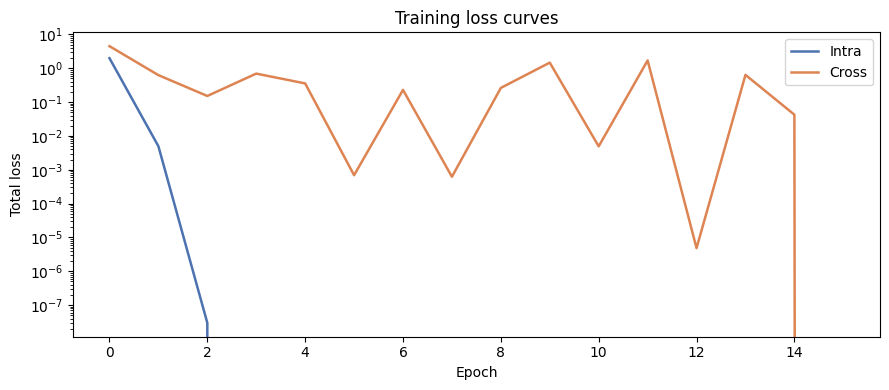

In [21]:
def plot_loss_curves(loss_histories, labels):
    """
    loss_histories : list of lists
    labels         : list of strings
    """
    fig, ax = plt.subplots(figsize=(9, 4))
    for history, label, color in zip(loss_histories, labels, COLORS):
        ax.plot(history, label=label, color=color, linewidth=1.8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Total loss")
    ax.set_title("Training loss curves")
    ax.legend()
    ax.set_yscale("log")   # log scale makes early + late convergence both visible
    plt.tight_layout()
    plt.savefig("figs/loss_curves.png", dpi=150)
    plt.show()

plot_loss_curves([loss_intra, loss_cross], ["Intra", "Cross"])

## Confusion

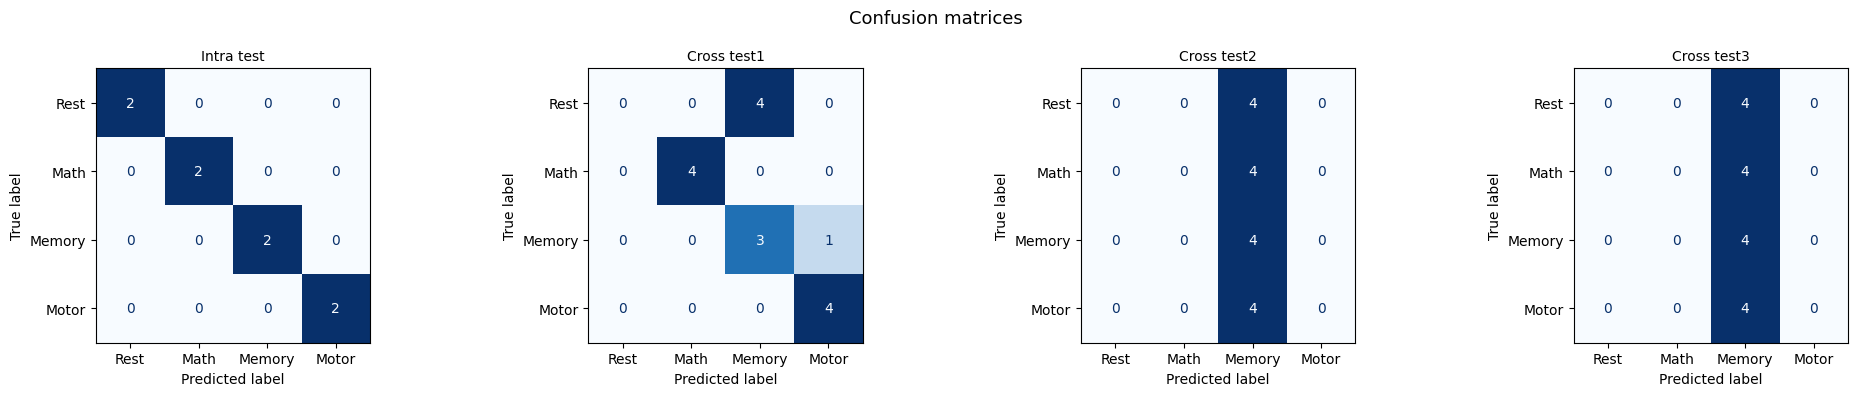

In [22]:
def get_predictions(model, x, y):
    """Returns (y_true, y_pred) as numpy arrays."""
    device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataset = Torchdata(x, y)
    loader  = DataLoader(dataset, batch_size=16)
    model.eval()
 
    all_preds = []
    all_true  = []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            outputs   = model(x_batch.to(device))
            _, preds  = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y_batch.numpy())
 
    return np.array(all_true), np.array(all_preds)
 
 
def plot_confusion_matrices(models_and_data, titles):
    """
    models_and_data : list of (model, x, y) tuples
    titles          : list of strings
    """
    n   = len(models_and_data)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
 
    for ax, (model, x, y), title in zip(axes, models_and_data, titles):
        y_true, y_pred = get_predictions(model, x, y)
        cm = confusion_matrix(y_true, y_pred, labels=list(range(4)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(title, fontsize=10)
 
    plt.suptitle("Confusion matrices", fontsize=13)
    plt.tight_layout()
    plt.savefig("figs/confusion_matrices.png", dpi=150)
    plt.show()
 
 
plot_confusion_matrices(
    [
        (model_intra, x_test_intra,   y_test_intra),
        (model_cross, x_test_cross1,  y_test_cross1),
        (model_cross, x_test_cross2,  y_test_cross2),
        (model_cross, x_test_cross3,  y_test_cross3),
    ],
    ["Intra test", "Cross test1", "Cross test2", "Cross test3"],
)
 

## Accuracy

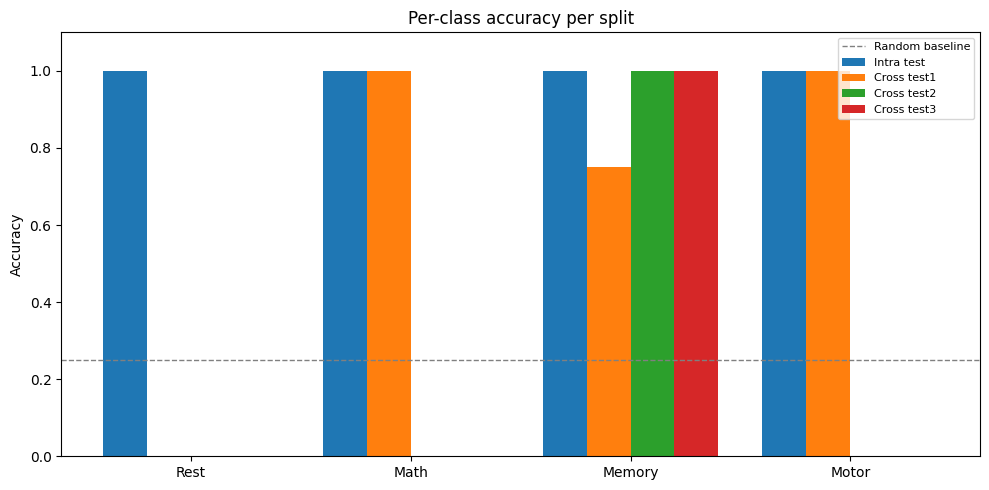

In [23]:
def plot_per_class_accuracy(models_and_data, split_names):
    """Shows per-class accuracy as a grouped bar chart across all splits."""
    results = {}  # split_name -> [acc_per_class]
 
    for (model, x, y), name in zip(models_and_data, split_names):
        y_true, y_pred = get_predictions(model, x, y)
        accs = []
        for cls in range(4):
            mask  = y_true == cls
            if mask.sum() == 0:
                accs.append(float("nan"))
            else:
                accs.append((y_pred[mask] == cls).mean())
        results[name] = accs
 
    x_pos = np.arange(4)
    width = 0.8 / len(results)
    fig, ax = plt.subplots(figsize=(10, 5))
 
    for i, (split_name, accs) in enumerate(results.items()):
        offset = (i - len(results) / 2 + 0.5) * width
        ax.bar(x_pos + offset, accs, width, label=split_name)
 
    ax.set_xticks(x_pos)
    ax.set_xticklabels(LABEL_NAMES)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="Random baseline")
    ax.set_ylabel("Accuracy")
    ax.set_title("Per-class accuracy per split")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("figs/per_class_accuracy.png", dpi=150)
    plt.show()
 
 
plot_per_class_accuracy(
    [
        (model_intra, x_test_intra,  y_test_intra),
        (model_cross, x_test_cross1, y_test_cross1),
        (model_cross, x_test_cross2, y_test_cross2),
        (model_cross, x_test_cross3, y_test_cross3),
    ],
    ["Intra test", "Cross test1", "Cross test2", "Cross test3"],
)

## Sensor activation map attempt

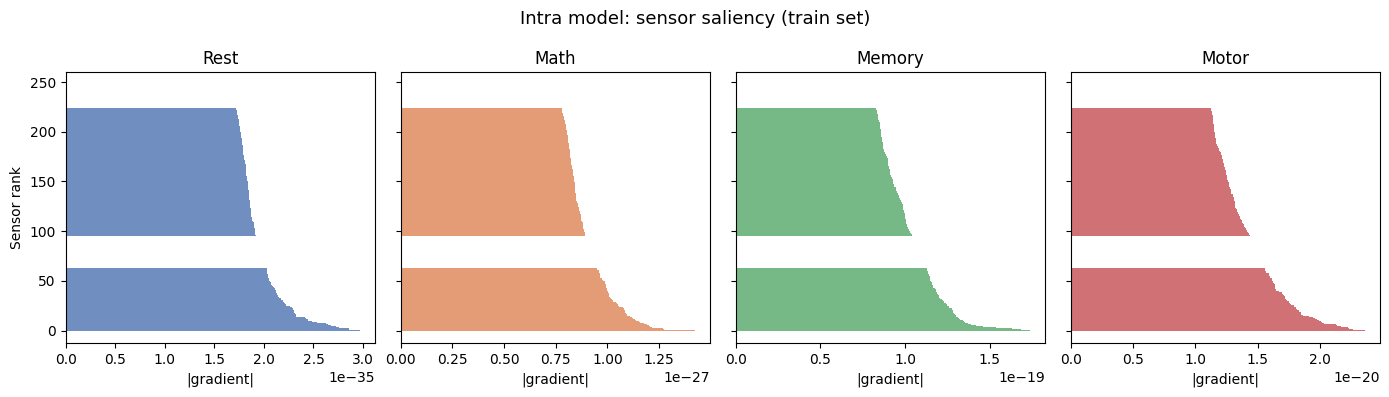

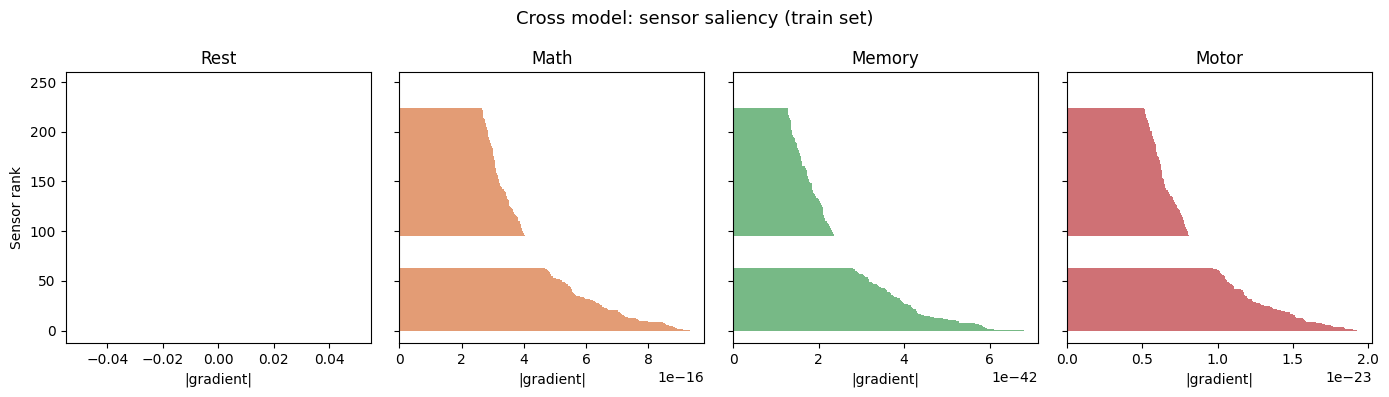

In [24]:
def compute_saliency(model, x, y, n_samples=None):
    """
    Returns mean absolute gradient per sensor (channel).
    Shape: (4 classes, n_channels)
    """
    device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
 
    if n_samples is not None:
        x = x[:n_samples]
        y = y[:n_samples]
 
    x_t = torch.tensor(x, dtype=torch.float32, requires_grad=True).to(device)
    y_t = torch.tensor(y, dtype=torch.long).to(device)
 
    outputs = model(x_t)
    loss    = torch.nn.CrossEntropyLoss()(outputs, y_t)
    loss.backward()
 
    # gradient shape: (n_samples, channels, timesteps)
    # mean over timesteps + samples, grouped by true class
    grads   = x_t.grad.detach().cpu().numpy()
    saliency_per_class = np.zeros((4, x.shape[1]))
 
    for cls in range(4):
        mask = y == cls
        if mask.sum() > 0:
            saliency_per_class[cls] = np.abs(grads[mask]).mean(axis=(0, 2))
 
    return saliency_per_class
 
 
def plot_saliency(model, x, y, title="Saliency: mean |gradient| per sensor"):
    saliency = compute_saliency(model, x, y)
 
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    fig.suptitle(title, fontsize=13)
 
    for cls, (ax, label, color) in enumerate(zip(axes, LABEL_NAMES, COLORS)):
        vals = saliency[cls]
        sorted_idx = np.argsort(vals)[::-1]
        ax.barh(range(len(vals)), vals[sorted_idx], color=color, alpha=0.8)
        ax.set_title(label)
        ax.set_xlabel("|gradient|")
        if cls == 0:
            ax.set_ylabel("Sensor rank")
 
    plt.tight_layout()
    plt.savefig("figs/saliency_per_class.png", dpi=150)
    plt.show()
 
 
plot_saliency(model_intra, x_train_intra, y_train_intra, "Intra model: sensor saliency (train set)")
plot_saliency(model_cross, x_train_cross, y_train_cross, "Cross model: sensor saliency (train set)")

## Sensor topology

In [25]:
def plot_topo_saliency(model, x, y, title="Topographic saliency"):
    saliency = compute_saliency(model, x, y)  # (4, 248)

    montage = mne.channels.make_standard_montage("CTF-275")
    info = mne.create_info(
        ch_names=montage.ch_names[:248],
        sfreq=203.4,
        ch_types="mag"
    )
    info.set_montage(montage)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(title, fontsize=13)

    for cls, (ax, label) in enumerate(zip(axes, LABEL_NAMES)):
        vals = saliency[cls]
        vals_norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-8)

        mne.viz.plot_topomap(
            vals_norm,
            info,
            axes=ax,
            show=False,
            cmap="hot",
            vlim=(0, 1),
        )
        ax.set_title(label)

    plt.tight_layout()
    plt.savefig("figs/topo_saliency.png", dpi=150)
    plt.show()
 
 
# plot_topo_saliency(model_intra, x_train_intra, y_train_intra, "Intra model: topographic saliency")

## Learned stuff

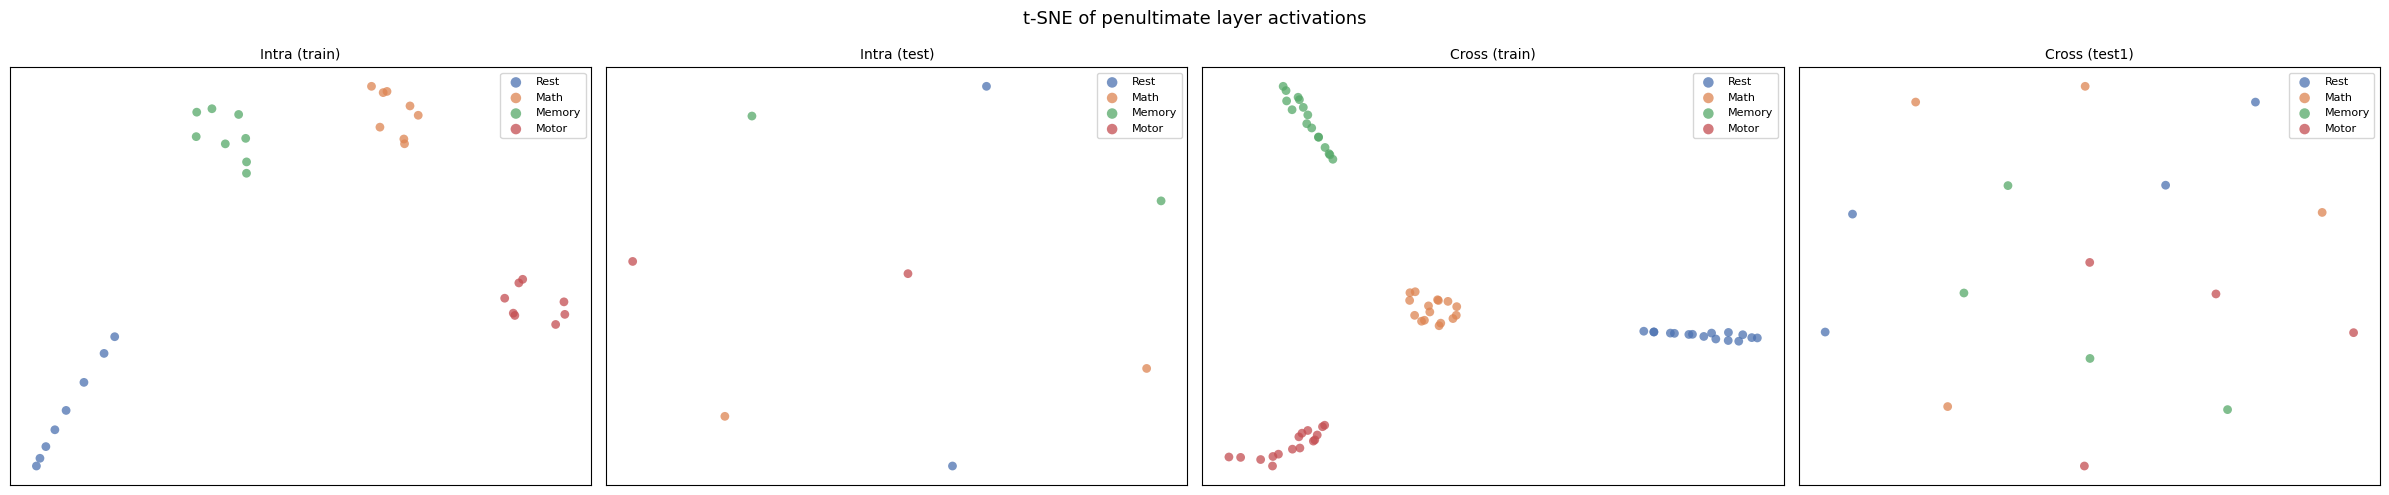

In [26]:
def extract_embeddings(model, x, y):
    """Returns (embeddings, labels) from the layer before the final fc2."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
 
    embeddings = []
    labels     = []
 
    # hook onto fc1 output
    activations = {}
    def hook_fn(module, input, output):
        activations["fc1"] = output.detach().cpu().numpy()
 
    handle = model.fc1.register_forward_hook(hook_fn)
 
    dataset = Torchdata(x, y)
    loader  = DataLoader(dataset, batch_size=16)
 
    with torch.no_grad():
        for x_batch, y_batch in loader:
            model(x_batch.to(device))
            embeddings.append(activations["fc1"])
            labels.extend(y_batch.numpy())
 
    handle.remove()
    return np.vstack(embeddings), np.array(labels)
 
 
def plot_tsne(models_and_data, titles, perplexity=15):
    from sklearn.manifold import TSNE
 
    n   = len(models_and_data)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
 
    for ax, (model, x, y), title in zip(axes, models_and_data, titles):
        emb, lbl = extract_embeddings(model, x, y)
        tsne     = TSNE(n_components=2, perplexity=min(perplexity, len(emb) - 1),
                        random_state=42)
        proj     = tsne.fit_transform(emb)
 
        for cls, (label_name, color) in enumerate(zip(LABEL_NAMES, COLORS)):
            mask = lbl == cls
            ax.scatter(proj[mask, 0], proj[mask, 1],
                       label=label_name, color=color,
                       s=40, alpha=0.75, edgecolors="none")
 
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8, markerscale=1.2)
        ax.set_xticks([])
        ax.set_yticks([])
 
    plt.suptitle("t-SNE of penultimate layer activations", fontsize=13)
    plt.tight_layout()
    plt.savefig("figs/tsne_embeddings.png", dpi=150)
    plt.show()
 
 
# Intra: does it separate on training data vs unseen test data?
plot_tsne(
    [
        (model_intra, x_train_intra,  y_train_intra),
        (model_intra, x_test_intra,   y_test_intra),
        (model_cross, x_train_cross,  y_train_cross),
        (model_cross, x_test_cross1,  y_test_cross1),
    ],
    ["Intra (train)", "Intra (test)", "Cross (train)", "Cross (test1)"],
)
 

## Summary

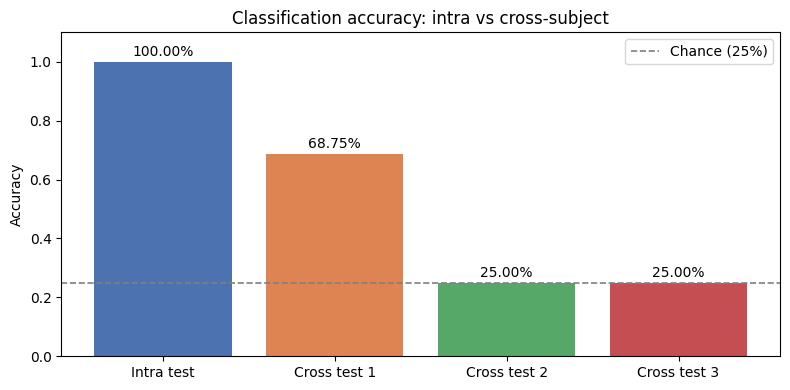


  Intra test
              precision    recall  f1-score   support

        Rest       1.00      1.00      1.00         2
        Math       1.00      1.00      1.00         2
      Memory       1.00      1.00      1.00         2
       Motor       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8


  Cross test1
              precision    recall  f1-score   support

        Rest       0.00      0.00      0.00         4
        Math       1.00      1.00      1.00         4
      Memory       0.43      0.75      0.55         4
       Motor       0.80      1.00      0.89         4

    accuracy                           0.69        16
   macro avg       0.56      0.69      0.61        16
weighted avg       0.56      0.69      0.61        16


  Cross test2
              precision    recall  f1-score   support

        Rest       0.00      0.

In [27]:
def plot_accuracy_summary(model_intra, model_cross,
                           x_test_intra,  y_test_intra,
                           x_test_cross1, y_test_cross1,
                           x_test_cross2, y_test_cross2,
                           x_test_cross3, y_test_cross3):
 
    splits = [
        ("Intra test",   model_intra, x_test_intra,  y_test_intra),
        ("Cross test 1", model_cross, x_test_cross1, y_test_cross1),
        ("Cross test 2", model_cross, x_test_cross2, y_test_cross2),
        ("Cross test 3", model_cross, x_test_cross3, y_test_cross3),
    ]
 
    names = []
    accs  = []
    for name, model, x, y in splits:
        _, y_pred = get_predictions(model, x, y)
        y_true, _ = get_predictions(model, x, y)  # reuse for consistency
        y_true, y_pred = get_predictions(model, x, y)
        accs.append((y_pred == y_true).mean())
        names.append(name)
 
    fig, ax = plt.subplots(figsize=(8, 4))
    bar_colors = [COLORS[0]] + COLORS[1:4]
    bars = ax.bar(names, accs, color=bar_colors)
    ax.axhline(0.25, color="gray", linestyle="--", linewidth=1.2, label="Chance (25%)")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Accuracy")
    ax.set_title("Classification accuracy: intra vs cross-subject")
    ax.legend()
 
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{acc:.2%}", ha="center", fontsize=10)
 
    plt.tight_layout()
    plt.savefig("figs/accuracy_summary.png", dpi=150)
    plt.show()
 
 
plot_accuracy_summary(
    model_intra, model_cross,
    x_test_intra,  y_test_intra,
    x_test_cross1, y_test_cross1,
    x_test_cross2, y_test_cross2,
    x_test_cross3, y_test_cross3,
)
 

def print_classification_reports(models_and_data, split_names):
    for (model, x, y), name in zip(models_and_data, split_names):
        y_true, y_pred = get_predictions(model, x, y)
        print(f"\n{'='*50}")
        print(f"  {name}")
        print('='*50)
        print(classification_report(y_true, y_pred,
                                    target_names=LABEL_NAMES,
                                    zero_division=0))
 
 
print_classification_reports(
    [
        (model_intra, x_test_intra,  y_test_intra),
        (model_cross, x_test_cross1, y_test_cross1),
        (model_cross, x_test_cross2, y_test_cross2),
        (model_cross, x_test_cross3, y_test_cross3),
    ],
    ["Intra test", "Cross test1", "Cross test2", "Cross test3"],
)